In [6]:
import json
import re
import matplotlib.pyplot as plt
from collections import defaultdict


def plot_task_boxplots(json_path, task_id):
    with open(json_path, "r") as f:
        data = json.load(f)

    # find the target task
    task = None
    for item in data:
        if str(item.get("task_id")) == str(task_id):
            task = item
            break

    if task is None:
        print(f"Task {task_id} not found")
        return

    exec_by_score = defaultdict(list)
    exec_custom_by_score = defaultdict(list)

    # find all solution ids (numbers like "141", "20", ...)
    solution_ids = [k for k in task.keys() if k.isdigit()]

    for sid in solution_ids:
        grade_key = f"grade-{sid}"
        if grade_key not in task:
            continue

        execution = task[grade_key].get("execution")
        execution_custom = task[grade_key].get("execution_custom")

        # find GPT evaluation scores corresponding to this solution
        gpt_keys = [k for k in task.keys() if re.match(r".*-" + sid + r"$", k) and k.startswith("gpt")]
        for gpt_key in gpt_keys:
            score = task[gpt_key]

            if execution is not None:
                exec_by_score[score].append(execution)

            if execution_custom is not None:
                exec_custom_by_score[score].append(execution_custom)

    # sort scores
    scores = sorted(exec_by_score.keys())

    exec_data = [exec_by_score[s] for s in scores]
    exec_custom_data = [exec_custom_by_score[s] for s in scores]

    # Plot execution
    plt.figure()
    plt.boxplot(exec_data, labels=scores)
    plt.xlabel("GPT Evaluation Score")
    plt.ylabel("Execution Score")
    plt.title(f"Task {task_id} - Execution vs GPT Score")
    plt.show()

    # Plot execution_custom
    plt.figure()
    plt.boxplot(exec_custom_data, labels=scores)
    plt.xlabel("GPT Evaluation Score")
    plt.ylabel("Execution Custom Score")
    plt.title(f"Task {task_id} - Execution Custom vs GPT Score")
    plt.show()



/tmp/ipykernel_298770/1736599847.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(exec_data, labels=scores)


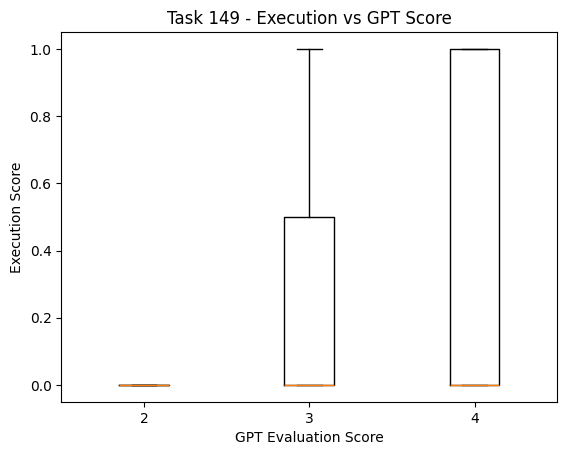

/tmp/ipykernel_298770/1736599847.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(exec_custom_data, labels=scores)


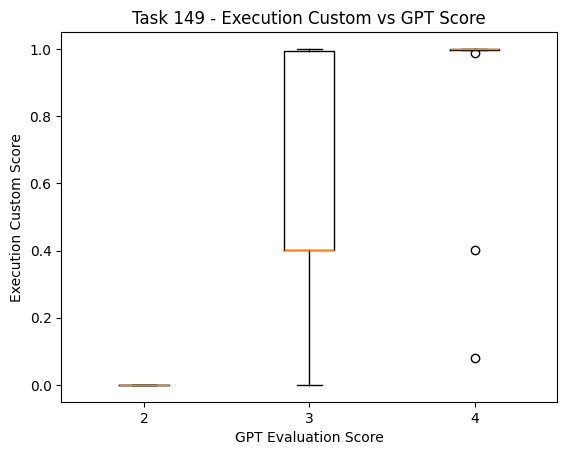

In [7]:
# example usage
plot_task_boxplots("./data/humaneval/humaneval_python_grade_evalplus_ratio.json", "149")